# Fetching Stock Market Data using yFinance 

### What is yFinance, and why should you use it?
yFinance is a Python library that connects directly to Yahoo Finance to fetch stock data. It’s useful for retrieving historical prices, financials, dividends, etc. It can be used, for example, to
- track historical stock performance
- analyze trends over time

In [442]:
# Install yfinance
# pip install yfinance

In [443]:
import yfinance as yf
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # To customize dates in plotting

### **1. One ticker symbol -- Microsoft Corp.**

In [445]:
# Example 1: Microsoft Corp.
dat = yf.Ticker("MSFT") # retrieve MSFT data
info_MSFT = dat.info # data dictionary containing info

# Take a subset of the dictionary above
# Subset using dict.get() to avoid KeyError if a key doesn't exist
subset = {key: info_MSFT.get(key) for key in ['shortName', 'revenueGrowth','ebitdaMargins','currentRatio','currentPrice']}
print('\033[1mThis is a subset of a data dictionary\033[0m\n',subset)

# Create DataFrame from the dictionary (Since the data is scalar, we need to pass an index)
df_info_MSFT = pd.DataFrame(subset, index=[0])

# Print the DataFrame (data table)
print('\n\033[1m.... converted to a data frame\033[0m\n',df_info_MSFT)

#dat.calendar 
#dat.analyst_price_targets
#dat.option_chain(dat.options[0]).calls

This is a subset of a data dictionary
 {'shortName': 'Microsoft Corporation', 'revenueGrowth': 0.123, 'ebitdaMargins': 0.54255, 'currentRatio': 1.351, 'currentPrice': 359.12}

.... converted to a data frame
                shortName  revenueGrowth  ebitdaMargins  currentRatio  \
0  Microsoft Corporation          0.123        0.54255         1.351   

   currentPrice  
0        359.12  


#### 1.1 Plot stock price over the past year

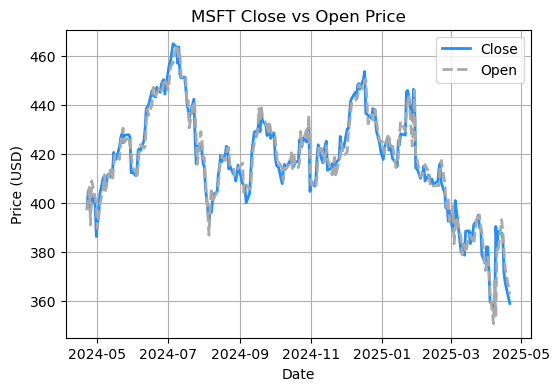

In [449]:
# Retrieve stock price for a year (already a data frame)
df_stockprice = dat.history(period='1y')

# Plot the 'Close' price and 'Open' price on the same plot
plt.figure(figsize=(6, 4))

# Plot 'Close' price
plt.plot(df_stockprice.index, df_stockprice['Close'], label='Close', color='dodgerblue', linestyle='-', linewidth=2)

# Plot 'Open' price
plt.plot(df_stockprice.index, df_stockprice['Open'], label='Open', color='darkgrey', linestyle='--', linewidth=2)

# Adding labels and title
plt.title('MSFT Close vs Open Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Adding a legend to distinguish the lines
plt.legend()

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()


#### 1.2 Get Microsoft's SEC Filings

In [453]:
# Get SEC Filings
sec_filing = dat.sec_filings
#print(sec_filing) # display

#### 1.2.1 Now let's focus on the 10-K filings

Check this link for more information: [https://www.investopedia.com/terms/1/10-k.asp](https://www.investopedia.com/terms/1/10-k.asp)

In [456]:
# Filter for 10-K filings
sec_filing_10k = [filing for filing in sec_filing if filing['type'] == '10-K']

# Display the 11-K filings
for filing in sec_filing_10k:
    print(f"Date: {filing['date']}")
    print(f"Title: {filing['title']}")
    print(f"EDGAR URL: {filing['edgarUrl']}")
    print(f"Exhibit URL: {filing['exhibits'].get('10-K')}")
    print('-' * 40)

Date: 2023-07-27
Title: Periodic Financial Reports
EDGAR URL: https://finance.yahoo.com/sec-filing/MSFT/0000950170-23-035122_789019
Exhibit URL: https://cdn.yahoofinance.com/prod/sec-filings/0000789019/000095017023035122/msft-20230630.htm
----------------------------------------
Date: 2022-07-28
Title: Periodic Financial Reports
EDGAR URL: https://finance.yahoo.com/sec-filing/MSFT/0001564590-22-026876_789019
Exhibit URL: https://cdn.yahoofinance.com/prod/sec-filings/0000789019/000156459022026876/msft-10k_20220630.htm
----------------------------------------


#### Note: Structure of a list comprehension

[expression for item in iterable if condition]

`expression`: The expression that defines what should go into the new list.

`item`: The current item being processed from the iterable (in this case, sec_filings).

`iterable`: The collection we are iterating over (here, it's the sec_filings list).

`condition`: An optional condition to filter which items should be included in the new list (this is the part after the if).

Thus, in the code:

[filing for filing in sec_filings if filing['type'] == '11-K']
- `filing`: This represents each individual item in the sec_filings list. Since sec_filings is a list of dictionaries (e.g. notice there are different dates and statements (11-K,8-K, etc.), filing will be a dictionary for each iteration.

- `for filing in sec_filings`: This part is the iteration part. It loops through each element in the sec_filings list. Each element (referred to as filing) is a dictionary containing information about an SEC filing.

- `if filing['type'] == '11-K'`: This is the filtering condition. It checks if the 'type' key in each filing dictionary is equal to '11-K'. If the condition is True, the filing will be included in the resulting list. If the condition is False, it will be excluded.

- `filing (in the list comprehension)`: This is the expression that determines what to include in the new list. In this case, it’s simply the filing itself (the whole dictionary), so we’re essentially gathering all filing dictionaries where the 'type' is '11-K'.


#### 1.3 Quarterly Financial Statement

In [460]:
qtr_fin_statement = dat.quarterly_income_stmt
print(qtr_fin_statement['2024-12-31'])

Tax Effect Of Unusual Items                                    -203220000.0
Tax Rate For Calcs                                                     0.18
Normalized EBITDA                                             37915000000.0
Total Unusual Items                                           -1129000000.0
Total Unusual Items Excluding Goodwill                        -1129000000.0
Net Income From Continuing Operation Net Minority Interest    24108000000.0
Reconciled Depreciation                                        6827000000.0
Reconciled Cost Of Revenue                                    21799000000.0
EBITDA                                                        36786000000.0
EBIT                                                          29959000000.0
Net Interest Income                                               6000000.0
Interest Expense                                                594000000.0
Interest Income                                                 600000000.0
Normalized I

### **2. Multiple ticker symbols**

In [463]:
# Example 2: Multiple ticker symbols
tickers = yf.Tickers('MSFT AAPL GOOG')
tickers.tickers['MSFT'].info
yf.download(['MSFT', 'AAPL', 'GOOG'], period='1y')

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        GOOG        MSFT        AAPL        GOOG   
Date                                                                     
2024-04-22  165.060608  157.205399  397.921997  166.473933  158.434577   
2024-04-23  166.115631  159.166122  404.481934  166.264935  159.723480   
2024-04-24  168.225677  160.340546  405.960602  168.504360  160.629172   
2024-04-25  169.091583  157.205399  396.016541  169.808201  157.533845   
2024-04-26  168.504349  172.871201  403.241425  170.534755  175.588327   
...                ...         ...         ...         ...         ...   
2025-04-14  202.520004  161.470001  387.809998  212.940002  164.029999   
2025-04-15  202.139999  158.679993  385.730011  203.509995  162.050003   
2025-04-16  194.270004  155.500000  371.609985  200.699997  158.179993   
2025-04-17  196.979996  153.360001  367.779999  198.830002  157.070007   
2025-04-21  193.160004  149.860001  359.119995  193.800003  151.059998   

Price                          Low                                Open  \
Ticker            MSFT        AAPL        GOOG        MSFT        AAPL   
Date                                                                     
2024-04-22  399.797691  163.995644  154.926201  392.751481  164.742120   
2024-04-23  405.107165  164.144941  157.220337  400.006095  164.572928   
2024-04-24  409.344768  165.428886  158.071295  403.697878  165.757322   
2024-04-25  396.860106  167.359755  152.047836  385.089952  168.733275   
2024-04-26  409.870805  168.384902  170.591987  402.685670  169.081625   
...                ...         ...         ...         ...         ...   
2025-04-14  394.649994  201.160004  159.919998  384.209991  211.440002   
2025-04-15  391.890015  199.800003  157.645004  384.160004  201.860001   
2025-04-16  381.609985  192.369995  153.910004  368.000000  198.360001   
2025-04-17  374.320007  194.419998  150.899994  366.890015  197.199997   
2025-04-21  364.480011  189.809998  148.399994  355.670013  193.270004   

Price                                  Volume                      
Ticker            GOOG        MSFT       AAPL      GOOG      MSFT  
Date                                                               
2024-04-22  155.274542  397.048660   48116400  17243900  20286900  
2024-04-23  157.842390  401.177147   49537800  16115400  15734500  
2024-04-24  158.340012  406.456813   48251800  19485700  15065300  
2024-04-25  152.637040  391.044491   50558300  36197800  40586500  
2024-04-26  175.160361  409.047107   44838400  56500800  29694700  
...                ...         ...        ...       ...       ...  
2025-04-14  162.309998  393.220001  101352900  18255900  19251200  
2025-04-15  161.570007  388.510010   51343900  15690800  17199900  
2025-04-16  155.470001  380.670013   59732400  16921500  21967800  
2025-04-17  156.610001  373.750000   51334300  19513400  20943700  
2025-04-21  150.964996  362.820007   46663300  16120200  20786800  

[250 rows x 15 columns]

[*********************100%***********************]  3 of 3 completed


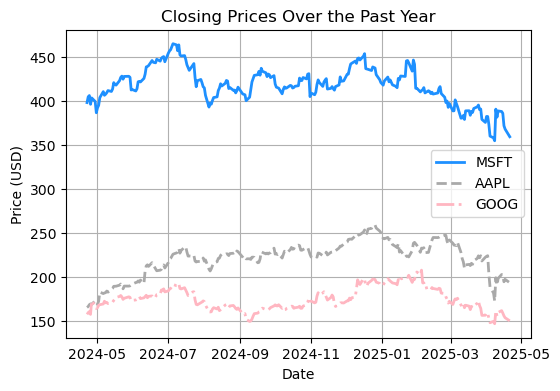

In [464]:
# Retrieve stock price for a year (already a data frame)
df_stocks_mult = tickers.history(period='1y')
df_stocks_close = df_stocks_mult['Close']

# Plot the 'Close' prices on the same plot
plt.figure(figsize=(6, 4))

# Plot MSFT price
plt.plot(df_stocks_close.index, df_stocks_close['MSFT'], label='MSFT', color='dodgerblue', linestyle='-', linewidth=2)

# Plot AAPL price
plt.plot(df_stocks_close.index, df_stocks_close['AAPL'], label='AAPL', color='darkgrey', linestyle='--', linewidth=2)

# Plot GOOG price
plt.plot(df_stocks_close.index, df_stocks_close['GOOG'], label='GOOG', color='lightpink', linestyle='-.', linewidth=2)

# Adding labels and title
plt.title('Closing Prices Over the Past Year')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Adding a legend to distinguish the lines
plt.legend()

# Show grid for better readability
plt.grid(True)

# Display the plot
plt.show()

### **3. Funds -- SPDR S&P 500 ETF**

In [468]:
# Example 3: Funds -- SPDR S&P 500 ETF
spy = yf.Ticker('SPY').funds_data
spy.description
spy.top_holdings

,Name,Holding Percent
Symbol,,
AAPL,Apple Inc,0.069951
MSFT,Microsoft Corp,0.058501
NVDA,NVIDIA Corp,0.055641
AMZN,Amazon.com Inc,0.037619
META,Meta Platforms Inc Class A,0.026459
BRK-B,Berkshire Hathaway Inc Class B,0.020464
GOOGL,Alphabet Inc Class A,0.018909
AVGO,Broadcom Inc,0.016452
GOOG,Alphabet Inc Class C,0.015483


### **4. US Treasury Yields**

In [471]:
# Retrieve data on US Treasury yields
US_bonds = yf.Tickers('^IRX ^FVX ^TNX ^TYX')

# Fetch historical data starting from 2020-01-02 
bonds_data = US_bonds.history(start='2020-01-02')

# Extract only the 'Close' prices
close_prices = bonds_data['Close']

# Display the data (optional)
print(close_prices.head())

# Export the data to csv format
close_prices.to_csv("us_bond_yields_close.csv")

[*********************100%***********************]  4 of 4 completed

Ticker       ^FVX   ^IRX   ^TNX   ^TYX
Date                                  
2020-01-02  1.671  1.495  1.882  2.341
2020-01-03  1.586  1.473  1.788  2.249
2020-01-06  1.611  1.488  1.811  2.281
2020-01-07  1.619  1.500  1.827  2.305
2020-01-08  1.665  1.493  1.874  2.358


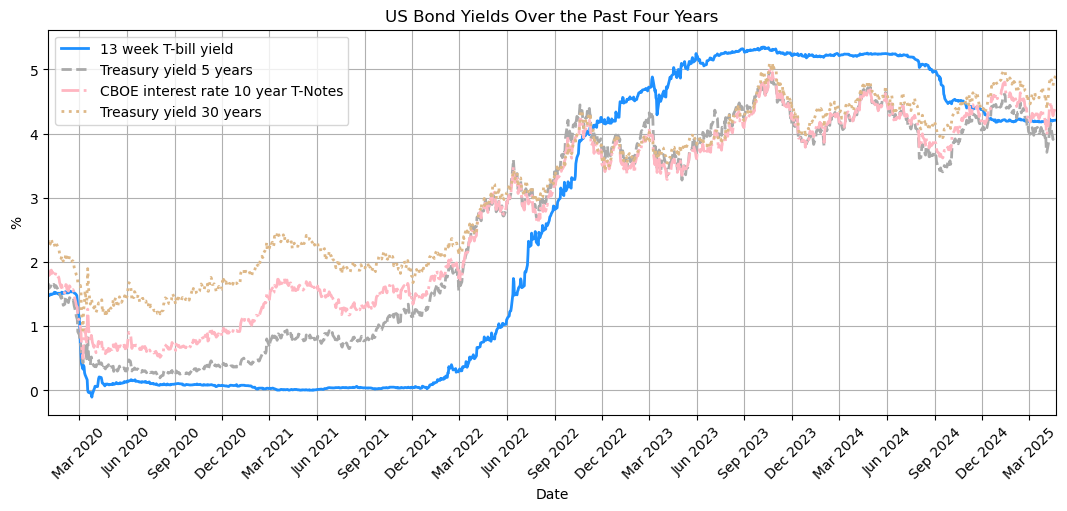

In [473]:
# Plot the 'Close' prices on the same plot
plt.figure(figsize=(13, 5))

# Plot 13 week T-bill yield
plt.plot(close_prices.index, close_prices['^IRX'], label='13 week T-bill yield', color='dodgerblue', linestyle='-', linewidth=2)

# Plot Treasury yield 5 years
plt.plot(close_prices.index, close_prices['^FVX'], label='Treasury yield 5 years', color='darkgrey', linestyle='--', linewidth=2)

# Plot CBOE interest rate 10 year T-Notes
plt.plot(close_prices.index, close_prices['^TNX'], label='CBOE interest rate 10 year T-Notes', color='lightpink', linestyle='-.', linewidth=2)

# Plot Treasury yield 30 years
plt.plot(close_prices.index, close_prices['^TYX'], label='Treasury yield 30 years', color='burlywood', linestyle=':', linewidth=2)

# Adding labels and title
plt.title('US Bond Yields Over the Past Four Years')
plt.xlabel('Date')
plt.ylabel('%')

# Format the x-axis for better date readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2020'

# Adding a legend to distinguish the lines
plt.legend()

# Show grid for better readability
plt.grid(True)

# Tilt x labels for readability
plt.xticks(rotation=45)  

# 🔒 Lock x-axis limits to data range
plt.xlim(close_prices.index.min(), close_prices.index.max())

# Display the plot
plt.show()

### Let's zoom in on the Trump "Liberation Day" tariffs

The tariffs were announced on April 2, 2025, and was subsequently "postponed" on April 9, 2025.

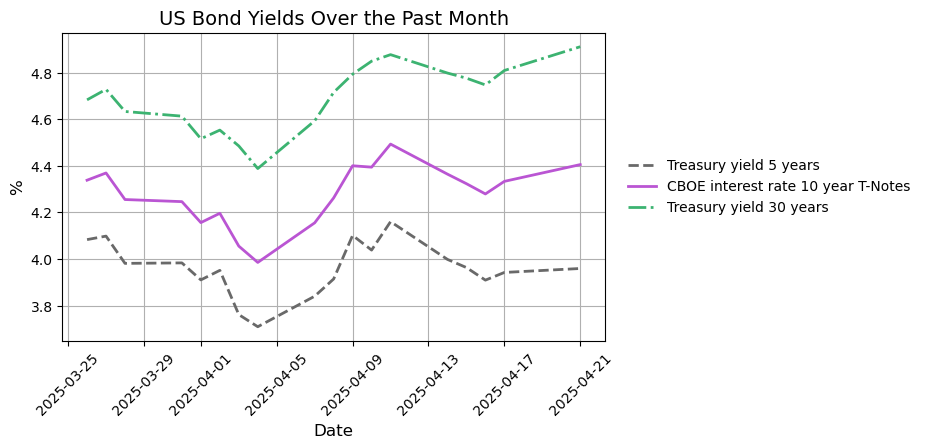

In [476]:
# 🔍 Filter to only show data from a specific start date
plot_start_date = '2025-03-26'
close_prices_trump = close_prices[close_prices.index >= plot_start_date]

# Plot the 'Close' prices on the same plot
plt.figure(figsize=(7, 4))

# Plot Treasury yield 5 years
plt.plot(close_prices_trump.index, close_prices_trump['^FVX'], label='Treasury yield 5 years', color='dimgrey', linestyle='--', linewidth=2)

# Plot CBOE interest rate 10 year T-Notes
plt.plot(close_prices_trump.index, close_prices_trump['^TNX'], label='CBOE interest rate 10 year T-Notes', color='mediumorchid', linestyle='-', linewidth=2)

# Plot Treasury yield 30 years
plt.plot(close_prices_trump.index, close_prices_trump['^TYX'], label='Treasury yield 30 years', color='mediumseagreen', linestyle='-.', linewidth=2)

# Adding labels and title
plt.title('US Bond Yields Over the Past Month', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('%', fontsize=12)

# Place legend below the plot, in one horizontal row
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),  # right side, centered vertically
    ncol=1,                      # one column (so rows stack)
    frameon=False
)

# Show grid for better readability
plt.grid(True)

# Tilt x labels for readability
plt.xticks(rotation=45)  

# Display the plot
plt.show()

### **5. Stock Indices**

In [489]:
# Retrieve data on major indices
major_indices = yf.Tickers('^GSPC ^DJI ^IXIC ^VIX ^FTSE ^STOXX50E')

# Fetch historical data starting from 2020-01-02 
stocks_data = major_indices.history(start='2020-01-02')

# Extract only the 'Close' prices
stock_close_price = stocks_data['Close']

# Export the data to csv format
stock_close_price.to_csv("stock_close_price.csv")

[*********************100%***********************]  6 of 6 completed


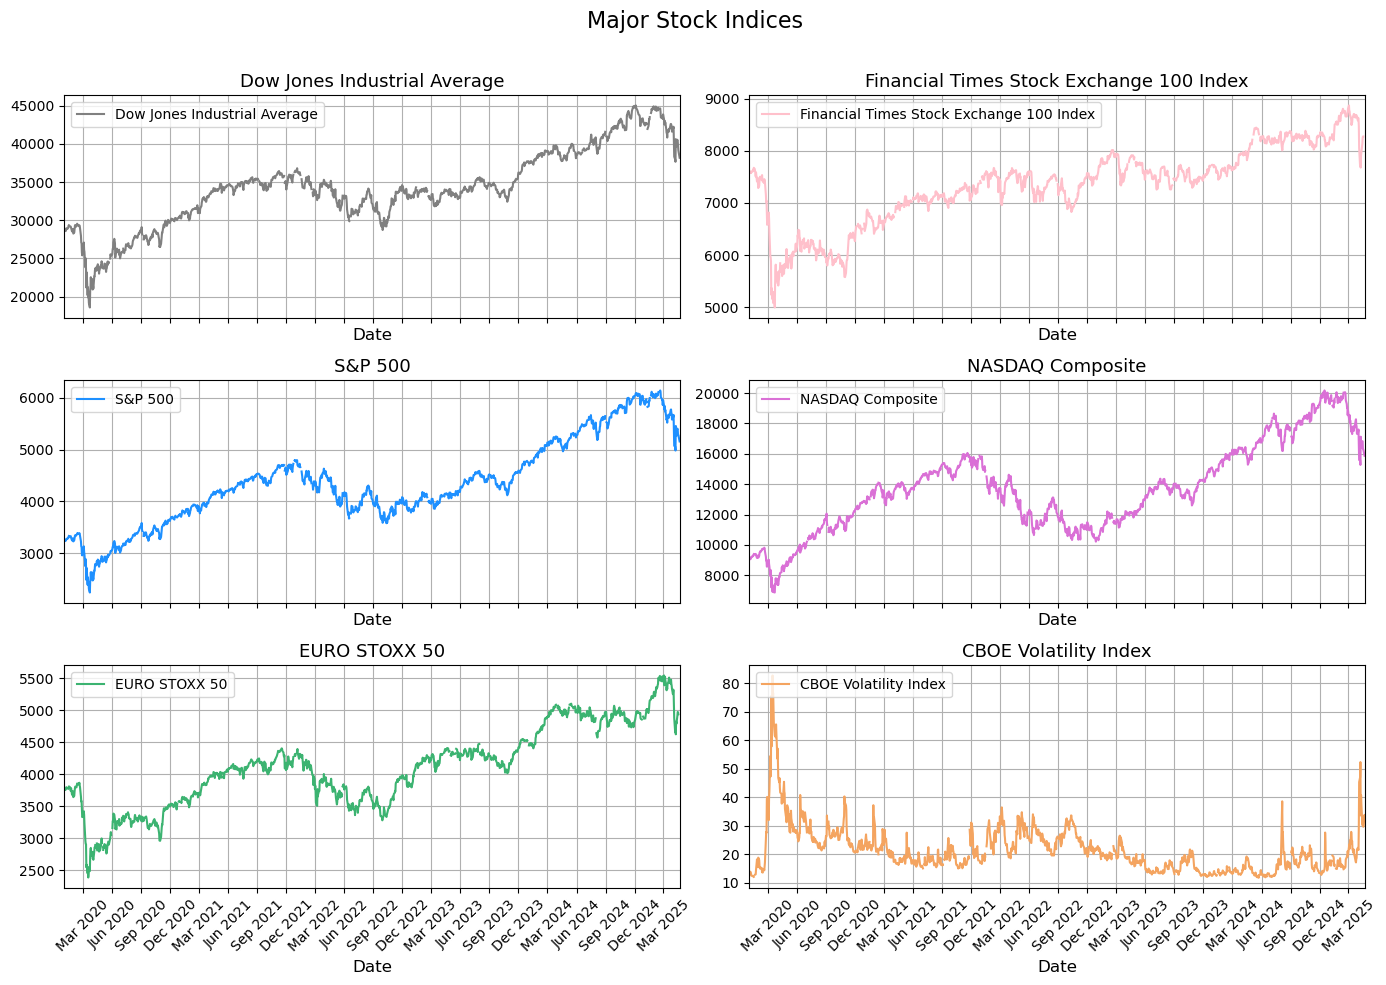

In [511]:
# Plot the 'Close' prices on different subplots

# Dynamically get only the tickers that have data
available_tickers = stock_close_price.columns.tolist()

# Colors (matplotlib default tab colors, or customize as you like)
colors = ['gray', 'pink', 'dodgerblue', 'orchid', 'mediumseagreen', 'sandybrown']

# Custom labels for each ticker
labels = {
    '^GSPC': 'S&P 500',
    '^DJI': 'Dow Jones Industrial Average',
    '^IXIC': 'NASDAQ Composite',
    '^VIX': 'CBOE Volatility Index',
    '^FTSE':'Financial Times Stock Exchange 100 Index',
    '^STOXX50E': 'EURO STOXX 50'
}

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axs = axs.flatten()  # Flatten to 1D array for easier looping

for i, ticker in enumerate(available_tickers):
    axs[i].plot(stock_close_price.index, 
                stock_close_price[ticker], 
                label=labels.get(ticker, ticker), 
                color=colors[i])
    axs[i].legend(loc='upper left', fontsize=10)
    axs[i].grid(True)
    axs[i].set_title(labels[ticker], fontsize=13)
    # Format x-axis
    axs[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axs[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].set_xlabel('Date', fontsize=12)
    axs[i].set_xlim(stock_close_price.index.min(), stock_close_price.index.max())

# Title and layout
plt.suptitle('Major Stock Indices', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

#### Miscellaneous: Python script to retrieve and save stock data
[https://www.linkedin.com/pulse/fetching-stock-market-data-made-simple-python-yfinance-prashant-singh-a2ysc](https://www.linkedin.com/pulse/fetching-stock-market-data-made-simple-python-yfinance-prashant-singh-a2ysc)